In [1]:
!git clone https://github.com/alihasnaink/beyond-iid

Cloning into 'beyond-iid'...
remote: Enumerating objects: 93, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 93 (delta 17), reused 86 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (93/93), 48.89 KiB | 3.49 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [2]:
!cd beyond-iid/domain-adaptation

In [3]:
import importlib.util, subprocess, sys
if importlib.util.find_spec("yaml") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyyaml"])

In [4]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image as DisplayImage, display
cwd = Path.cwd().resolve()
candidates = [cwd / "domain-adaptation", cwd, cwd.parent]
candidates += list(cwd.glob("*/domain-adaptation"))
TASK_DIR = next((p for p in candidates if p.exists() and p.name == "domain-adaptation"), cwd / "domain-adaptation")
REPO_ROOT = TASK_DIR.parent
for path in [TASK_DIR, REPO_ROOT]:
    if str(path) not in sys.path: sys.path.insert(0, str(path))
from shared.pacs import find_pacs_root
from train import train_suite
from evaluate_final import evaluate_suite
PACS_ROOT = "/kaggle/input/datasets/nickfratto/pacs-dataset/pacs_data/pacs_data"
resolved_pacs_root = find_pacs_root(PACS_ROOT)
print({"task_dir": str(TASK_DIR), "pacs_root": str(resolved_pacs_root)})

{'task_dir': '/kaggle/working/beyond-iid/domain-adaptation', 'pacs_root': '/kaggle/input/datasets/nickfratto/pacs-dataset/pacs_data/pacs_data'}


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s] 


,run_name,method,main_comparison,checkpoint,grl_max_strength,alignment_weight
0,source_only,source_only,True,/kaggle/working/beyond-iid/shared/checkpoints/...,NaN,0.0
1,dan,dan,True,/kaggle/working/beyond-iid/domain-adaptation/r...,NaN,1.0
2,dann,dann,True,/kaggle/working/beyond-iid/domain-adaptation/r...,1.00,1.0
3,cdan,cdan,True,/kaggle/working/beyond-iid/domain-adaptation/r...,1.00,1.0
4,dann_alpha_0p25,dann,False,/kaggle/working/beyond-iid/domain-adaptation/r...,0.25,1.0
5,dann_alpha_0p5,dann,False,/kaggle/working/beyond-iid/domain-adaptation/r...,0.50,1.0


,method,epoch,mean_source_val_macro_f1,classification_loss,alignment_loss,total_loss,domain_accuracy,val_photo_accuracy,val_photo_macro_f1,val_art_painting_accuracy,val_art_painting_macro_f1,val_cartoon_accuracy,val_cartoon_macro_f1
9,source_only,10,0.9169,0.0803,0.0000,0.0803,0.0000,0.9371,0.9298,0.8854,0.8836,0.9318,0.9372
15,dan,6,0.0507,1.9242,0.0023,1.9265,0.0000,0.2575,0.0585,0.2195,0.0514,0.1727,0.0421
29,dann,14,0.0364,21.8494,16.1750,38.0244,0.5030,0.1228,0.0312,0.1244,0.0316,0.1940,0.0464
44,cdan,15,0.9202,0.0690,0.6965,0.7656,0.5409,0.9431,0.9336,0.8902,0.8930,0.9254,0.9339
54,dann_alpha_0p25,10,0.2816,1.6366,0.7545,2.3911,0.4939,0.5090,0.3127,0.3171,0.2291,0.3646,0.3030
62,dann_alpha_0p5,8,0.1482,2.0584,1.2466,3.3050,0.5051,0.3713,0.1622,0.2537,0.1229,0.2324,0.1595


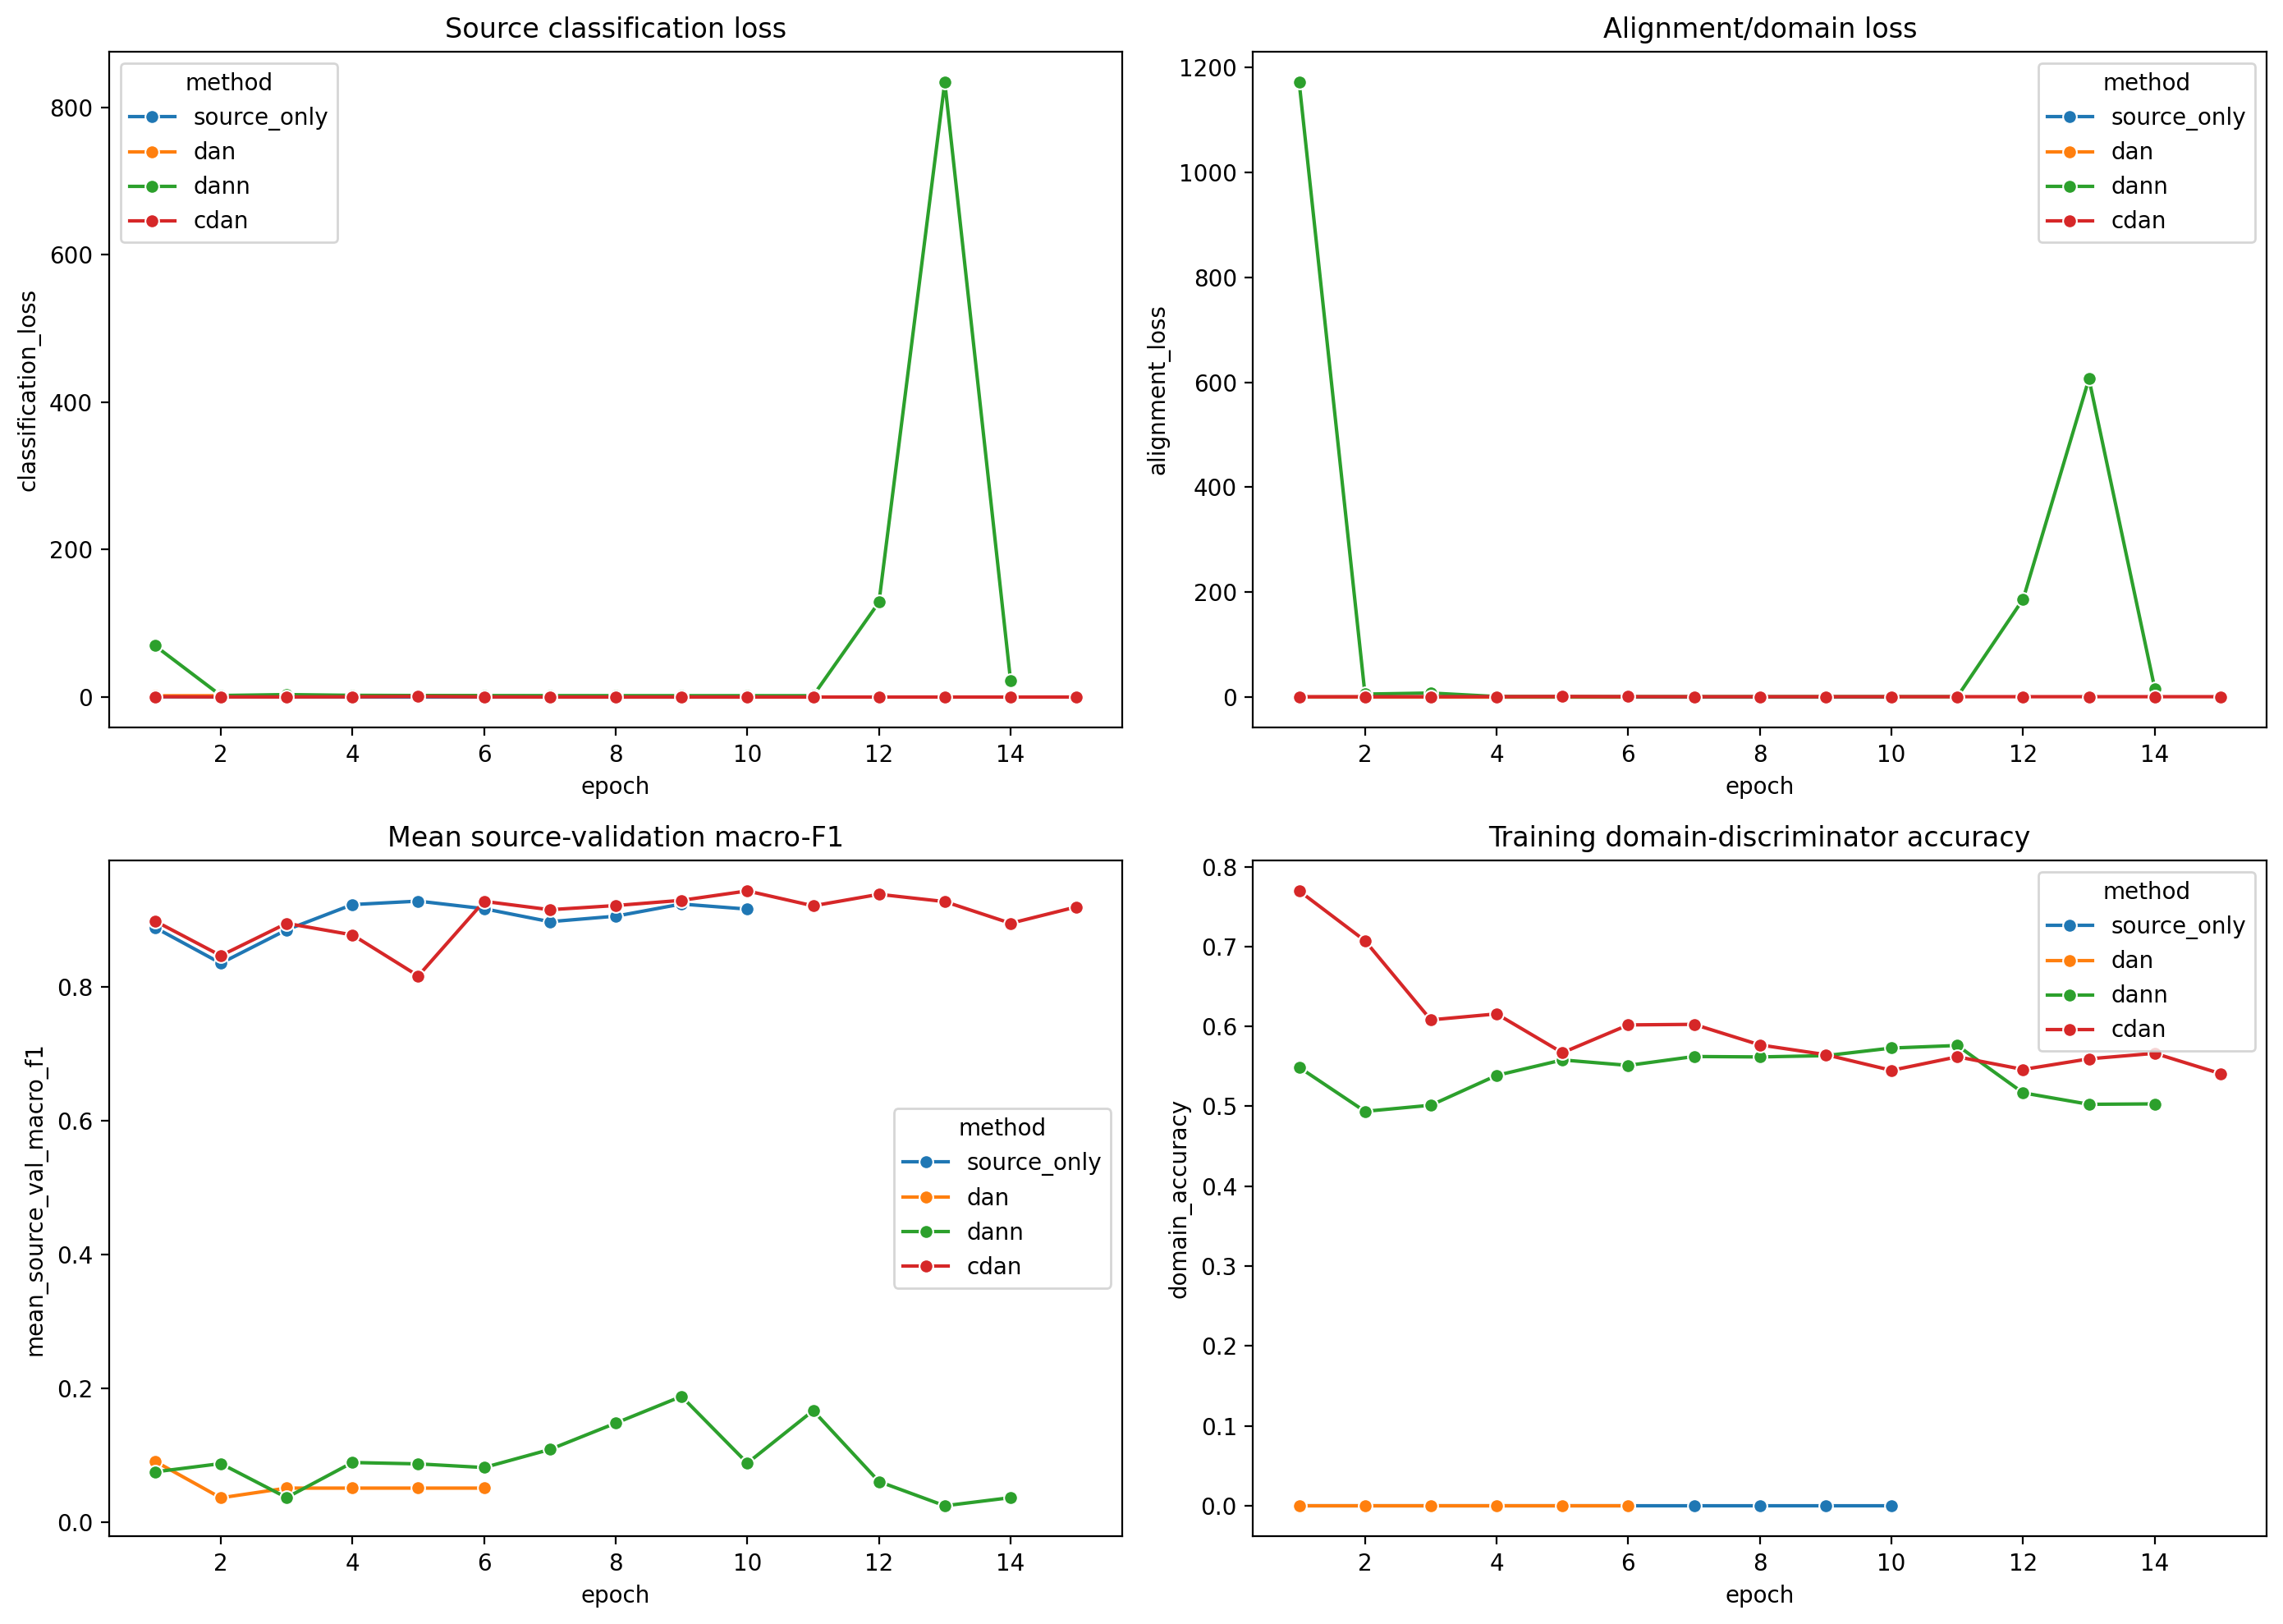

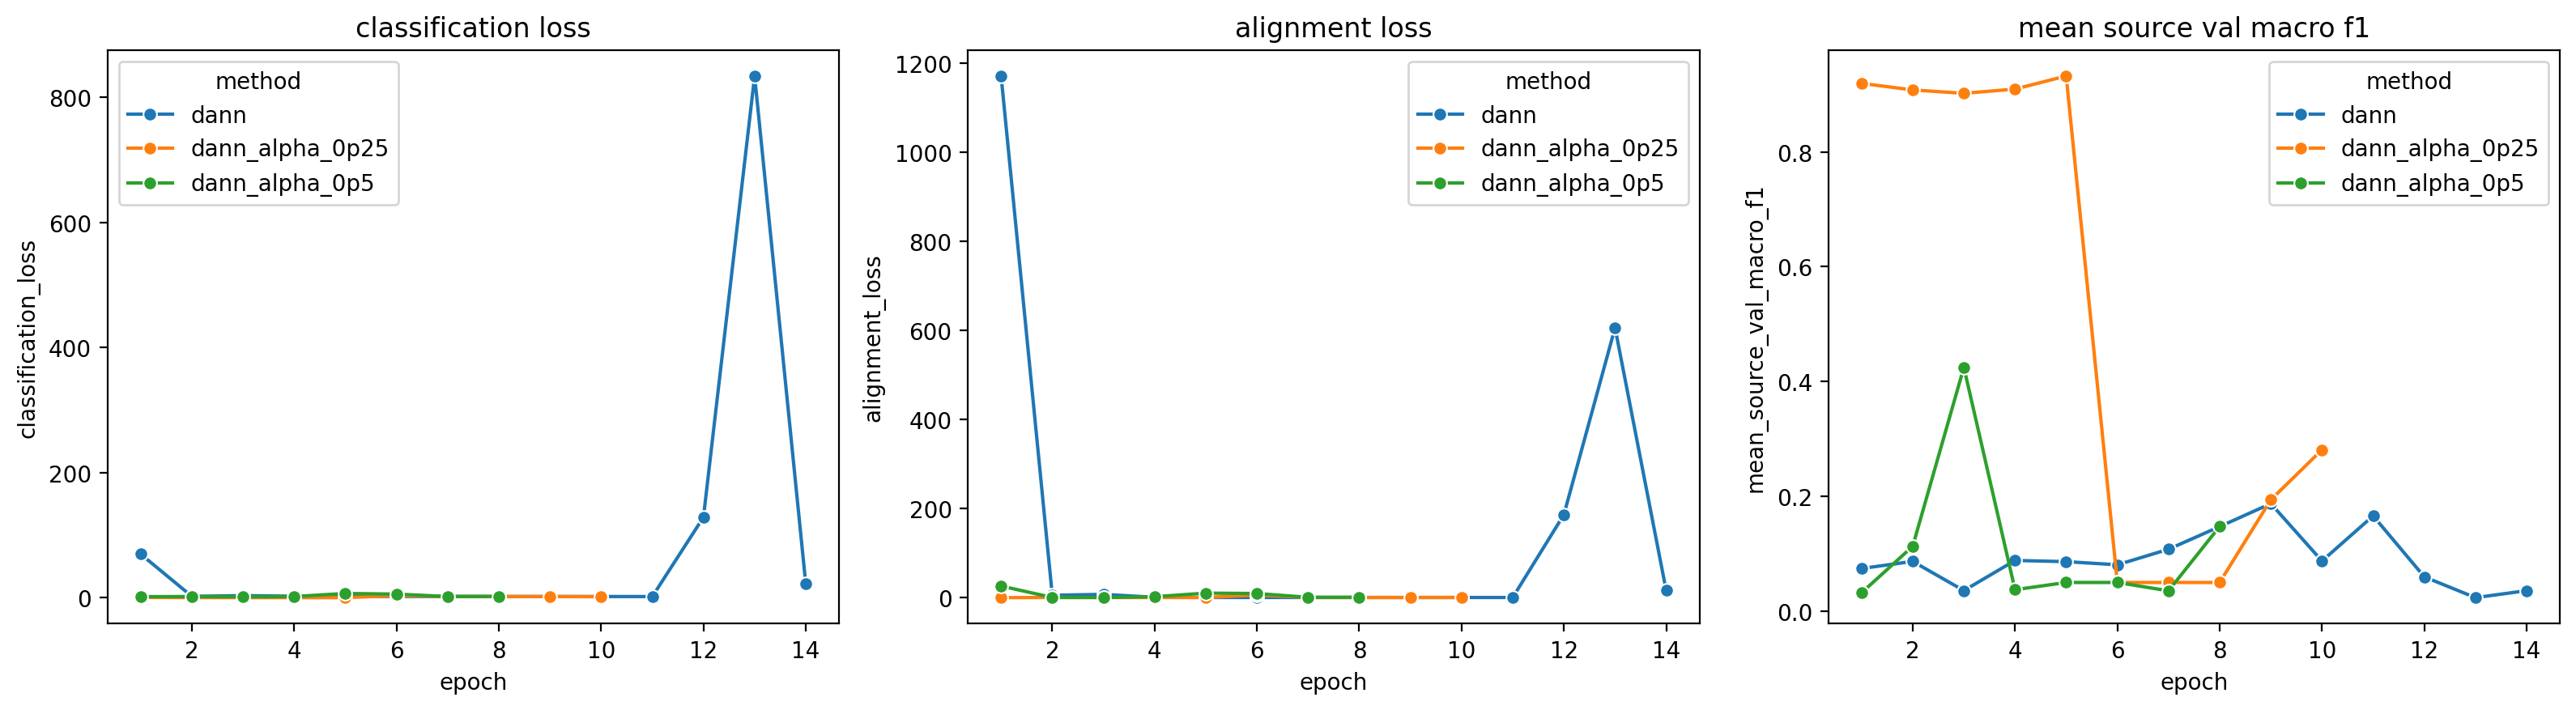

In [5]:
training = train_suite(resolved_pacs_root, TASK_DIR, include_study=True, force=False)
display(training["run_manifest"])
display(training["histories"].groupby("method").tail(1).round(4))
display(DisplayImage(filename=str(TASK_DIR / "results/main_training_curves.png"), width=1050))
display(DisplayImage(filename=str(TASK_DIR / "results/dann_strength_training_curves.png"), width=1050))

In [7]:
CONFIGURATIONS_LOCKED = True
assert CONFIGURATIONS_LOCKED, (
    "Paused before loading Sketch labels. Confirm the complete experimental design is locked, "
    "then set CONFIGURATIONS_LOCKED=True and rerun this cell."
)

In [9]:
final = evaluate_suite(resolved_pacs_root, TASK_DIR)

,method,main_comparison,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1,mean_source_accuracy,mean_source_macro_f1,target_accuracy,target_macro_f1,domain_separability,target_accuracy_change_vs_source_only,source_to_target_gap
0,source_only,True,0.9671,0.9626,0.8878,0.8827,0.9339,0.9412,0.9296,0.9288,0.6312,0.6436,0.9973,0.0000,0.2984
1,dan,True,0.3593,0.1782,0.1244,0.0438,0.1855,0.0505,0.2231,0.0908,0.1654,0.0459,0.7212,-0.4658,0.0576
2,dann,True,0.4012,0.2680,0.2171,0.1529,0.2345,0.1427,0.2843,0.1879,0.1883,0.0453,0.9904,-0.4429,0.0959
3,cdan,True,0.9731,0.9686,0.9098,0.9107,0.9467,0.9531,0.9432,0.9441,0.7574,0.7656,0.9904,0.1262,0.1857


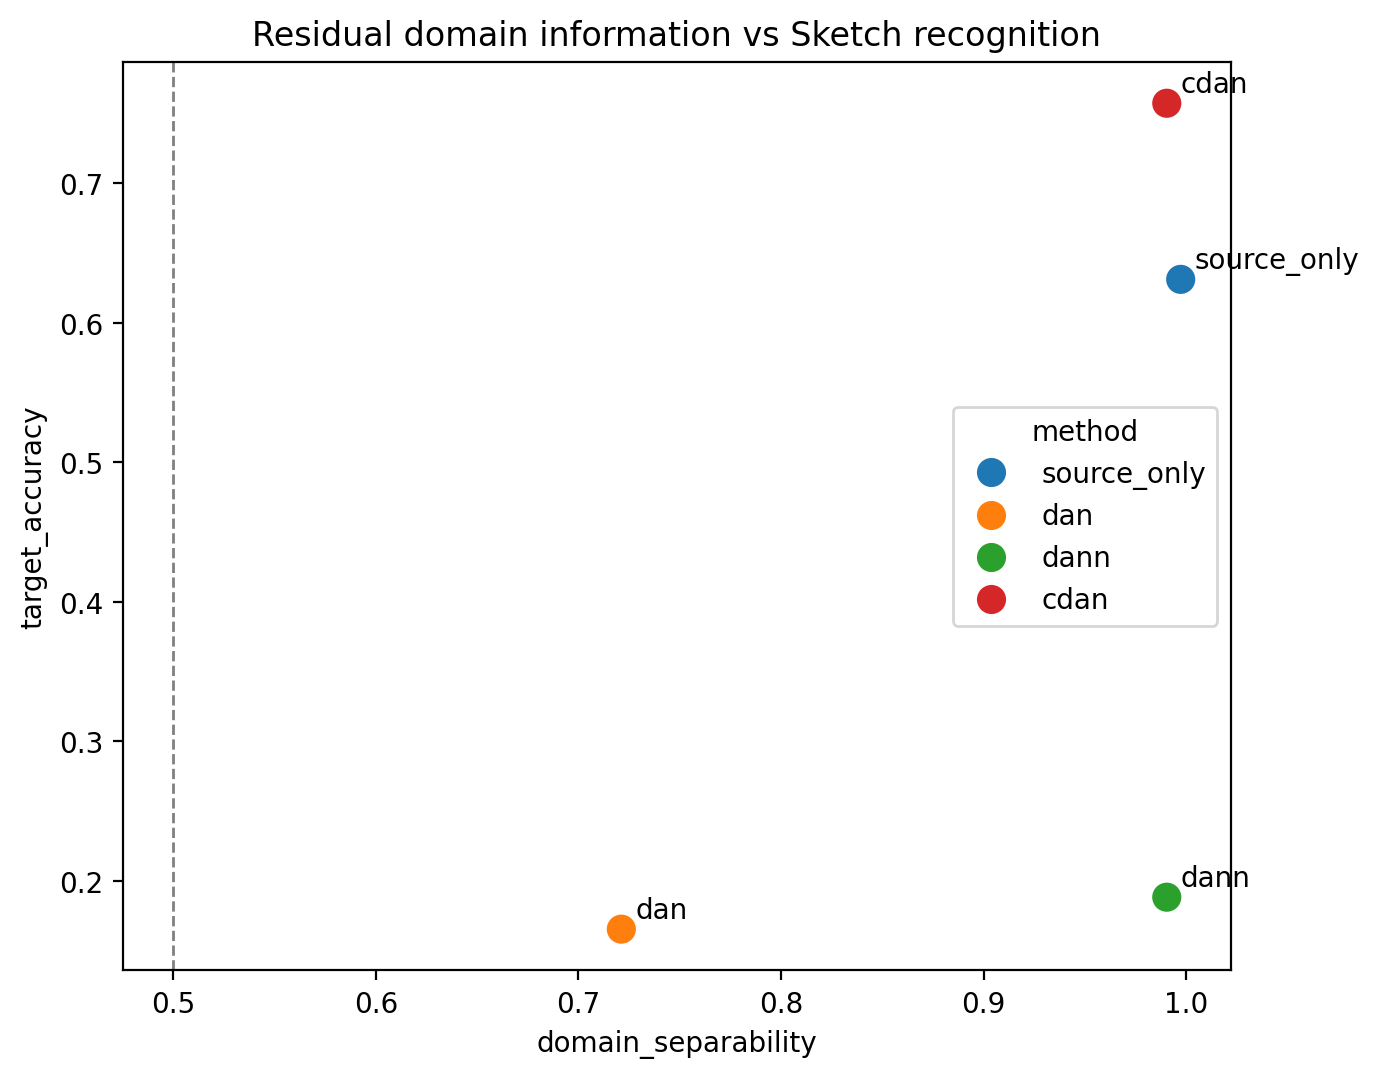

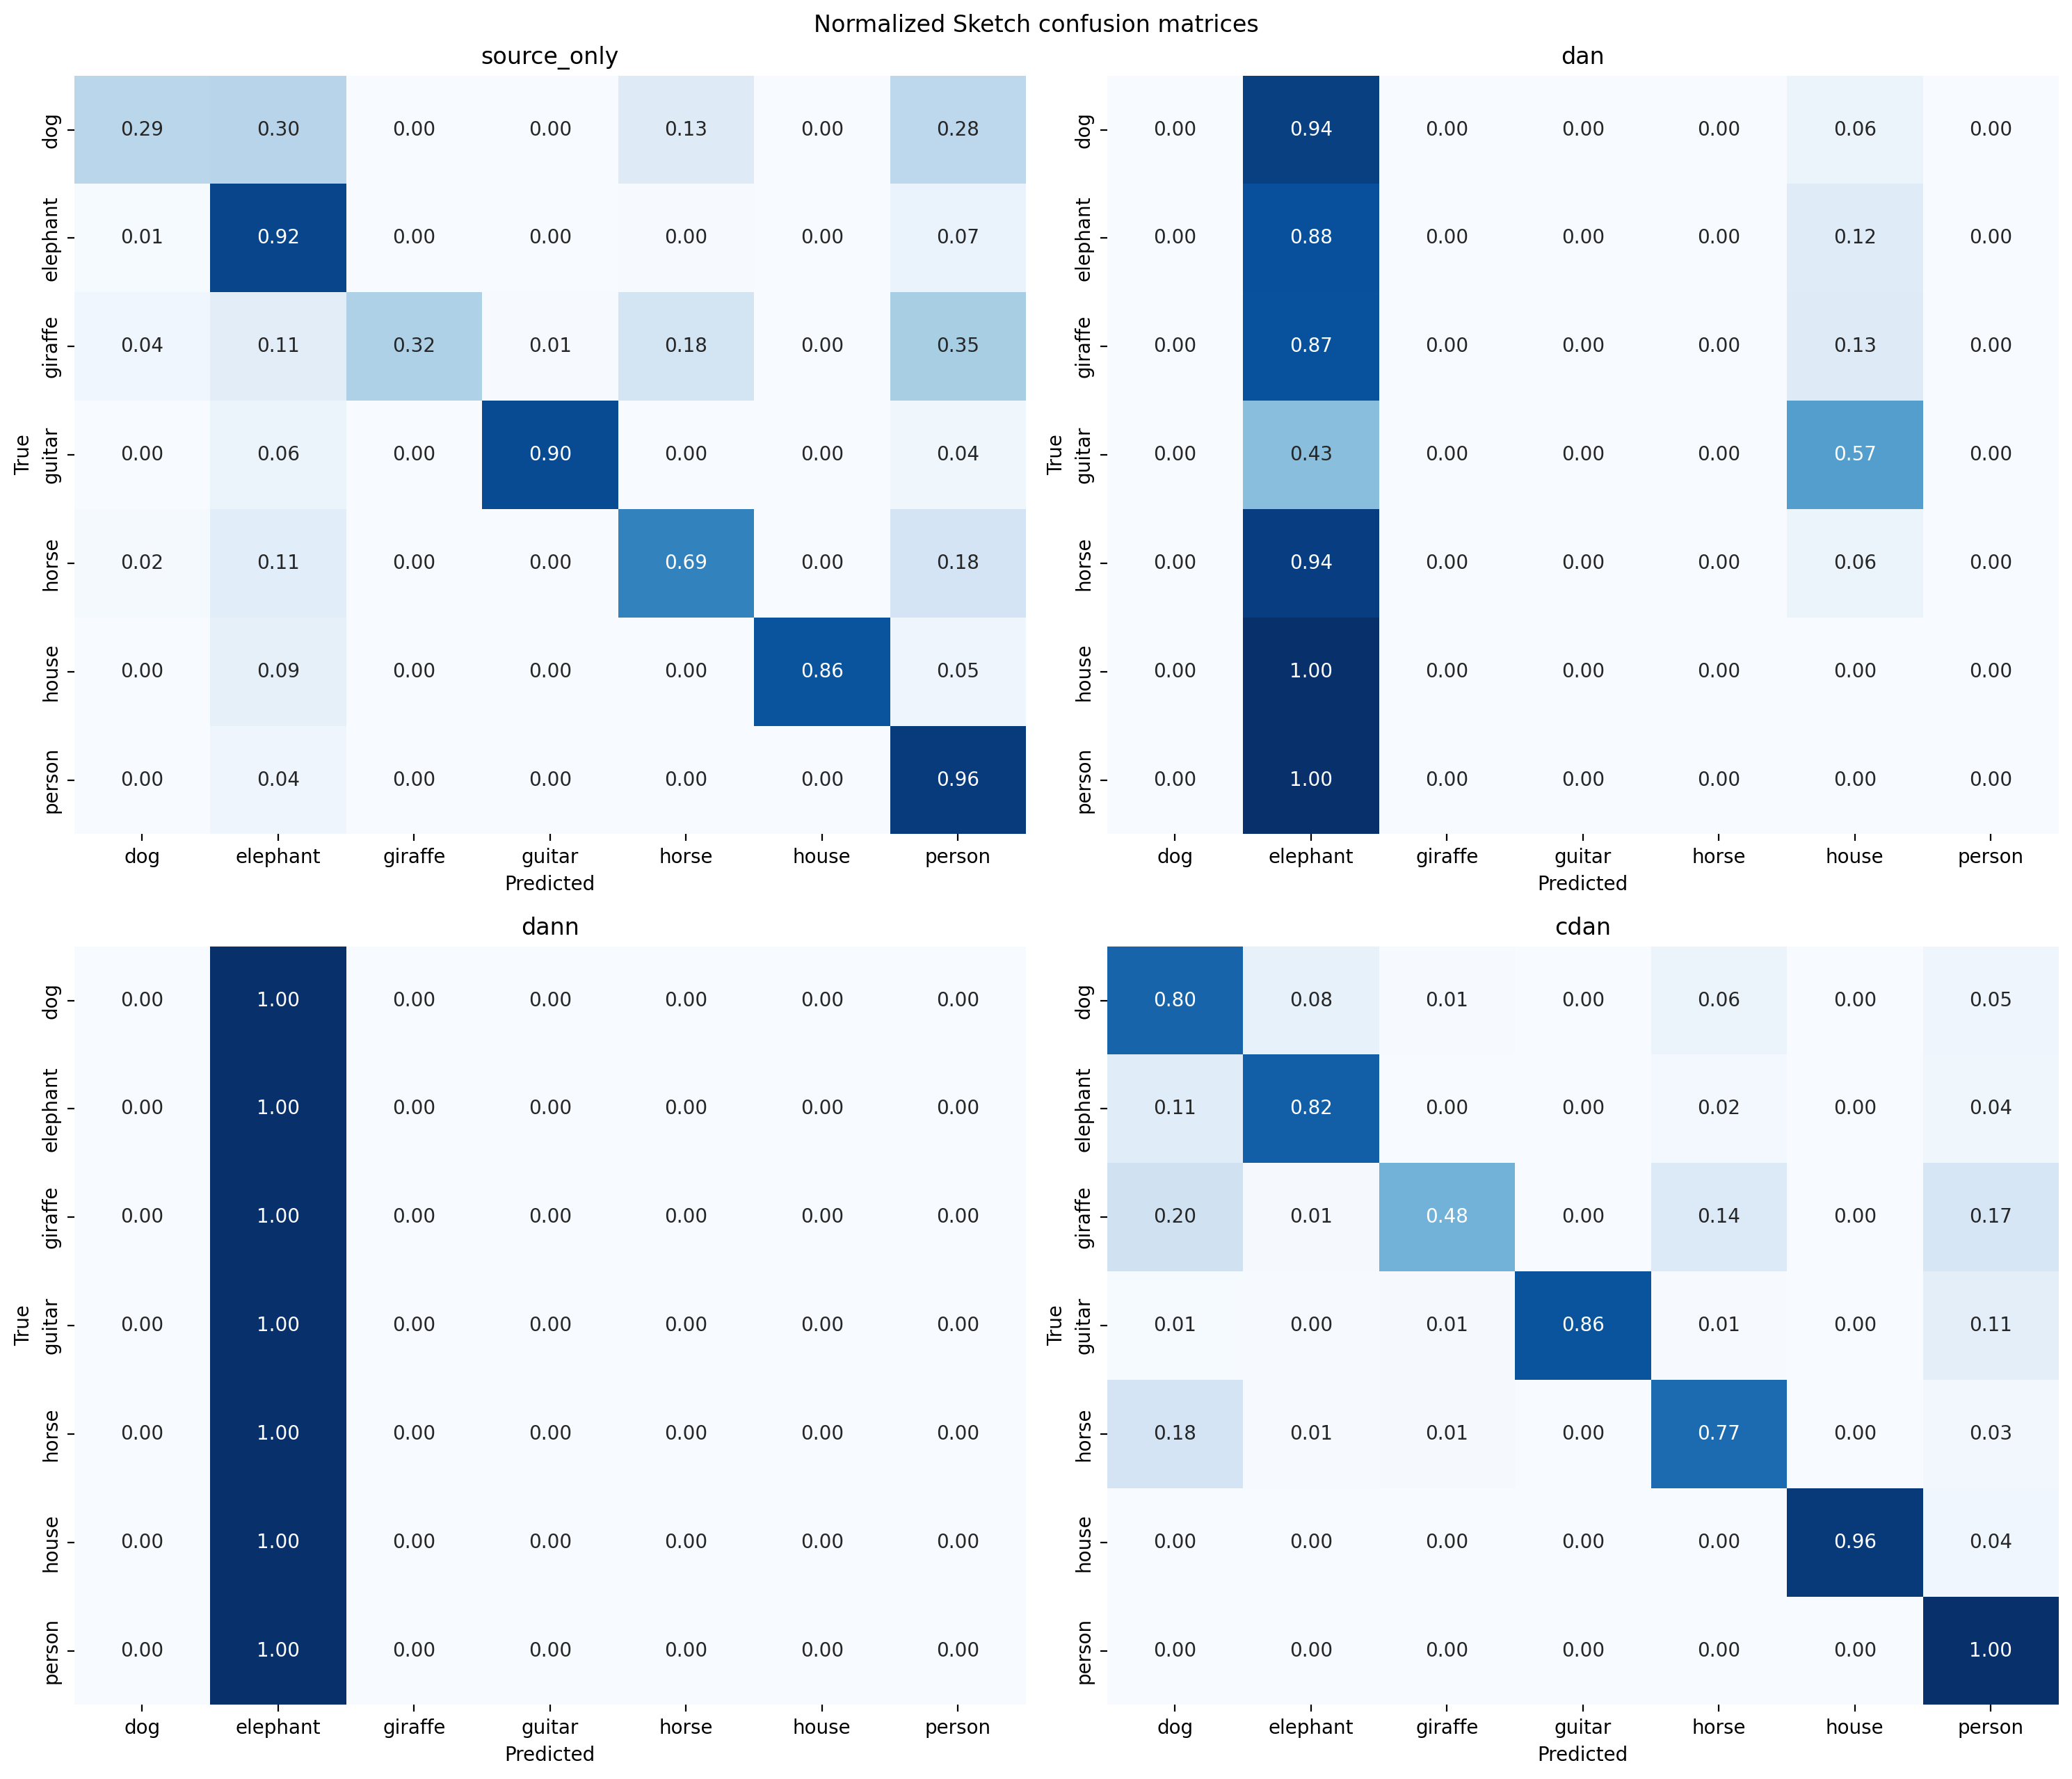

In [11]:
display(final["main_comparison"].round(4))
display(DisplayImage(filename=str(TASK_DIR / "results/domain_separability_vs_target_accuracy.png"), width=750))
display(DisplayImage(filename=str(TASK_DIR / "results/target_confusion_matrices.png"), width=1050))

,method,class_name,target_class_accuracy,change_vs_source_only,dominant_incorrect_prediction,class_count
0,source_only,dog,0.2927,0.0000,elephant,772
1,source_only,elephant,0.9216,0.0000,person,740
2,source_only,giraffe,0.3240,0.0000,person,753
3,source_only,guitar,0.8980,0.0000,elephant,608
4,source_only,horse,0.6863,0.0000,person,816
5,source_only,house,0.8625,0.0000,elephant,80
6,source_only,person,0.9562,0.0000,elephant,160
7,dan,dog,0.0000,-0.2927,elephant,772
8,dan,elephant,0.8784,-0.0432,house,740
9,dan,giraffe,0.0000,-0.3240,elephant,753


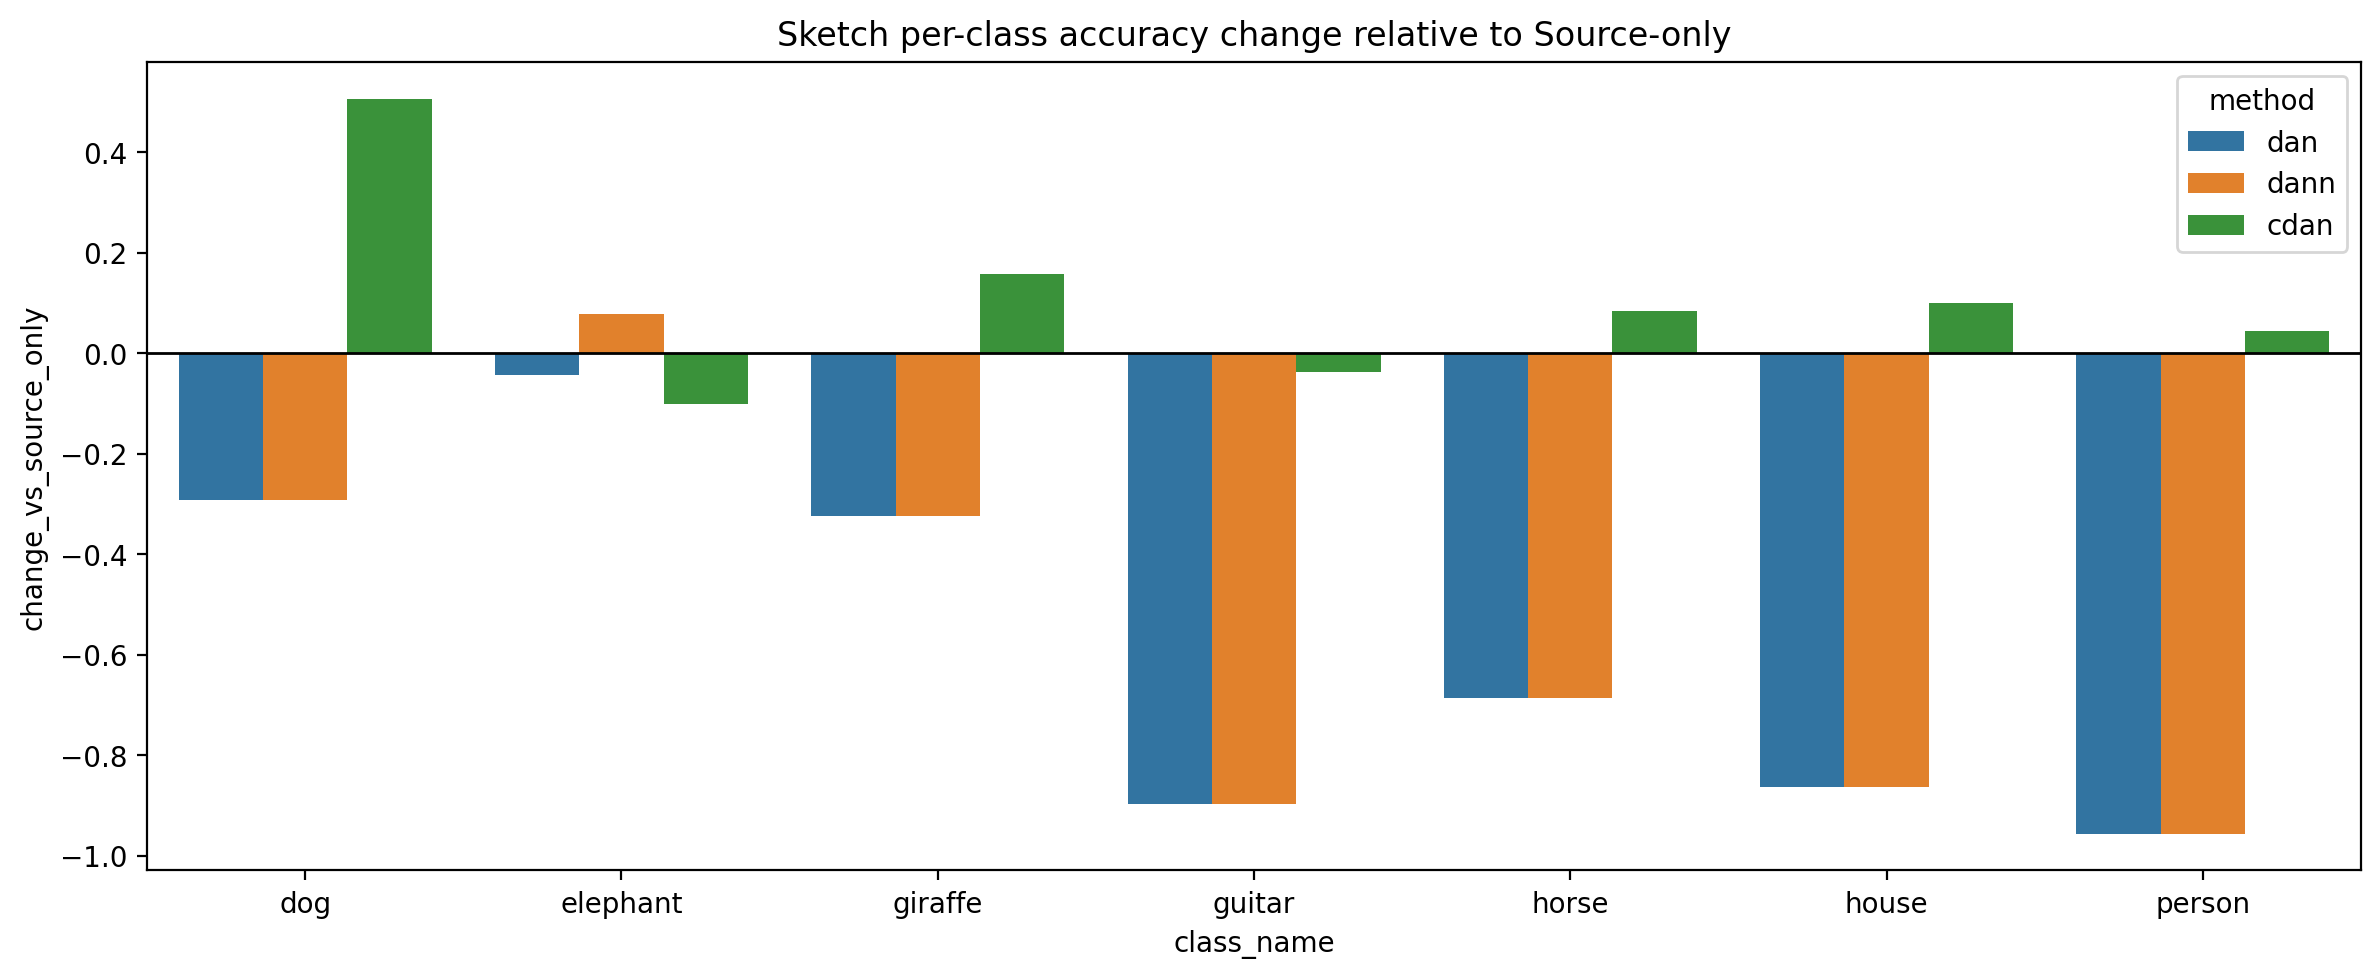

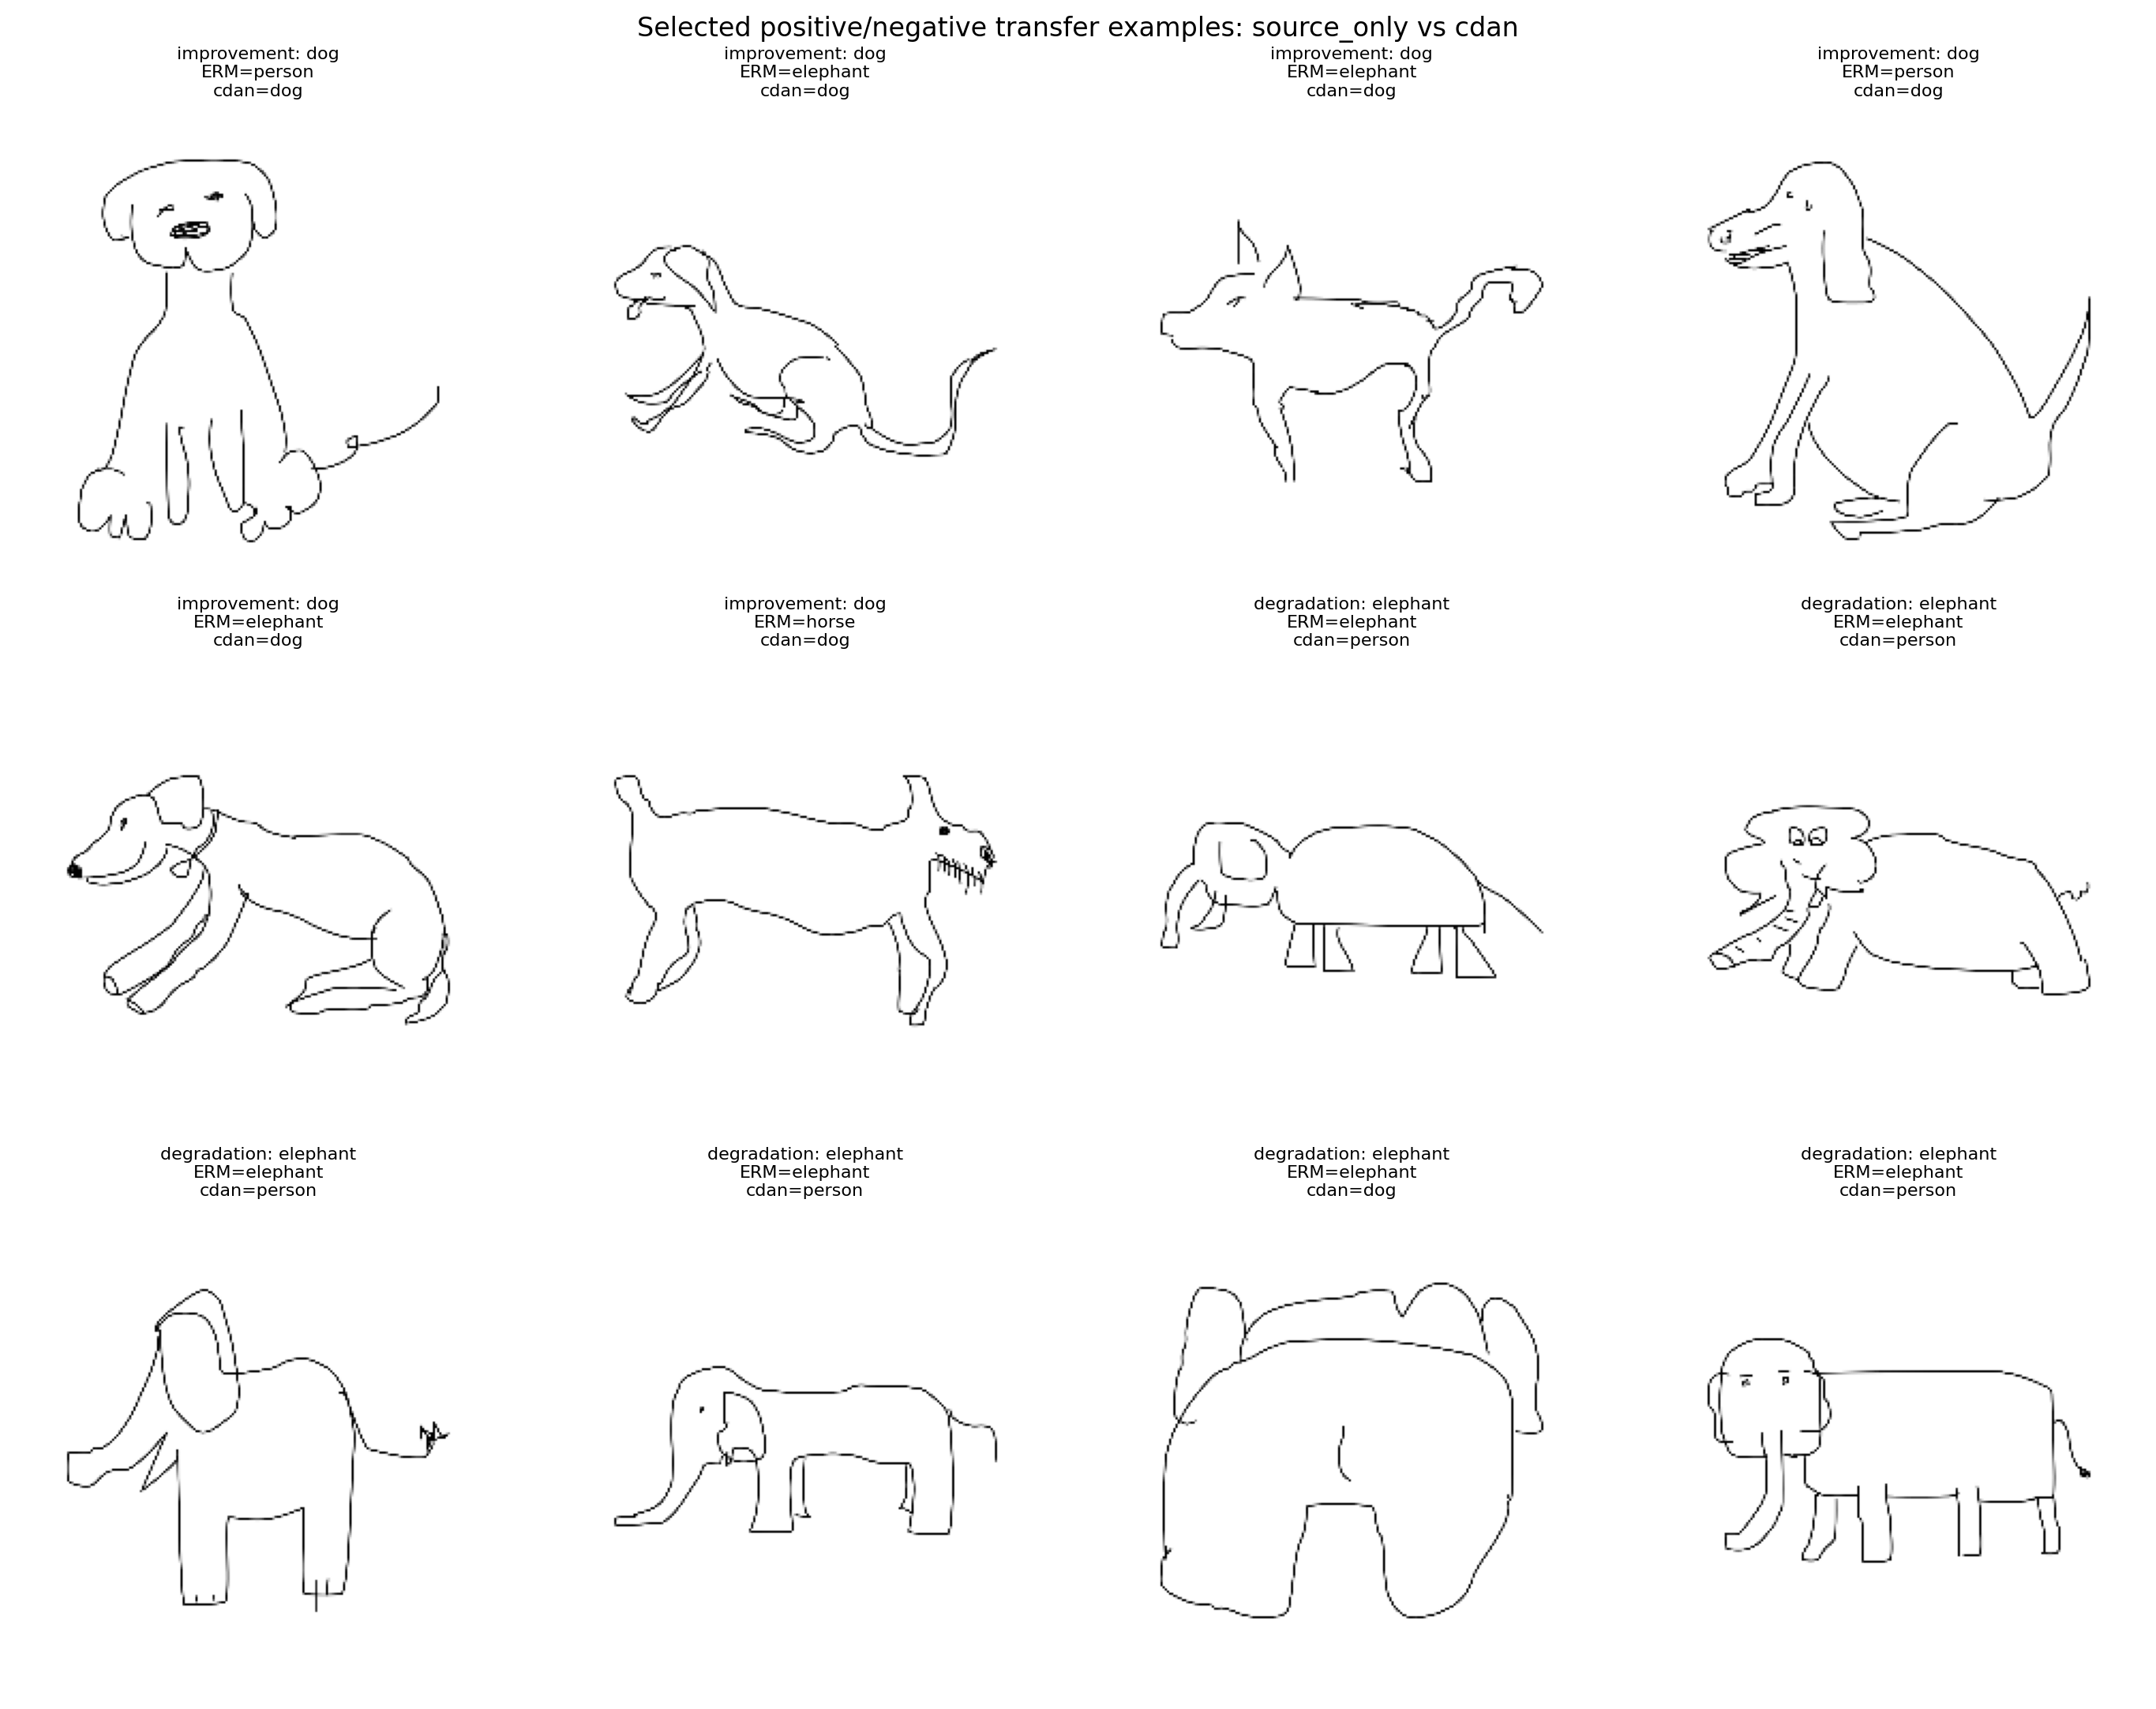

In [12]:
display(final["per_class"].round(4))
display(DisplayImage(filename=str(TASK_DIR / "results/target_per_class_accuracy_changes.png"), width=1000))
display(DisplayImage(filename=str(TASK_DIR / "results/selected_target_failure_cases.png"), width=1000))

,grl_max_strength,mean_source_accuracy,mean_source_macro_f1,target_accuracy,target_macro_f1,domain_separability
4,0.25,0.9276,0.9319,0.6205,0.5778,0.9945
5,0.50,0.5051,0.4250,0.1738,0.1684,0.9849
2,1.00,0.2843,0.1879,0.1883,0.0453,0.9904


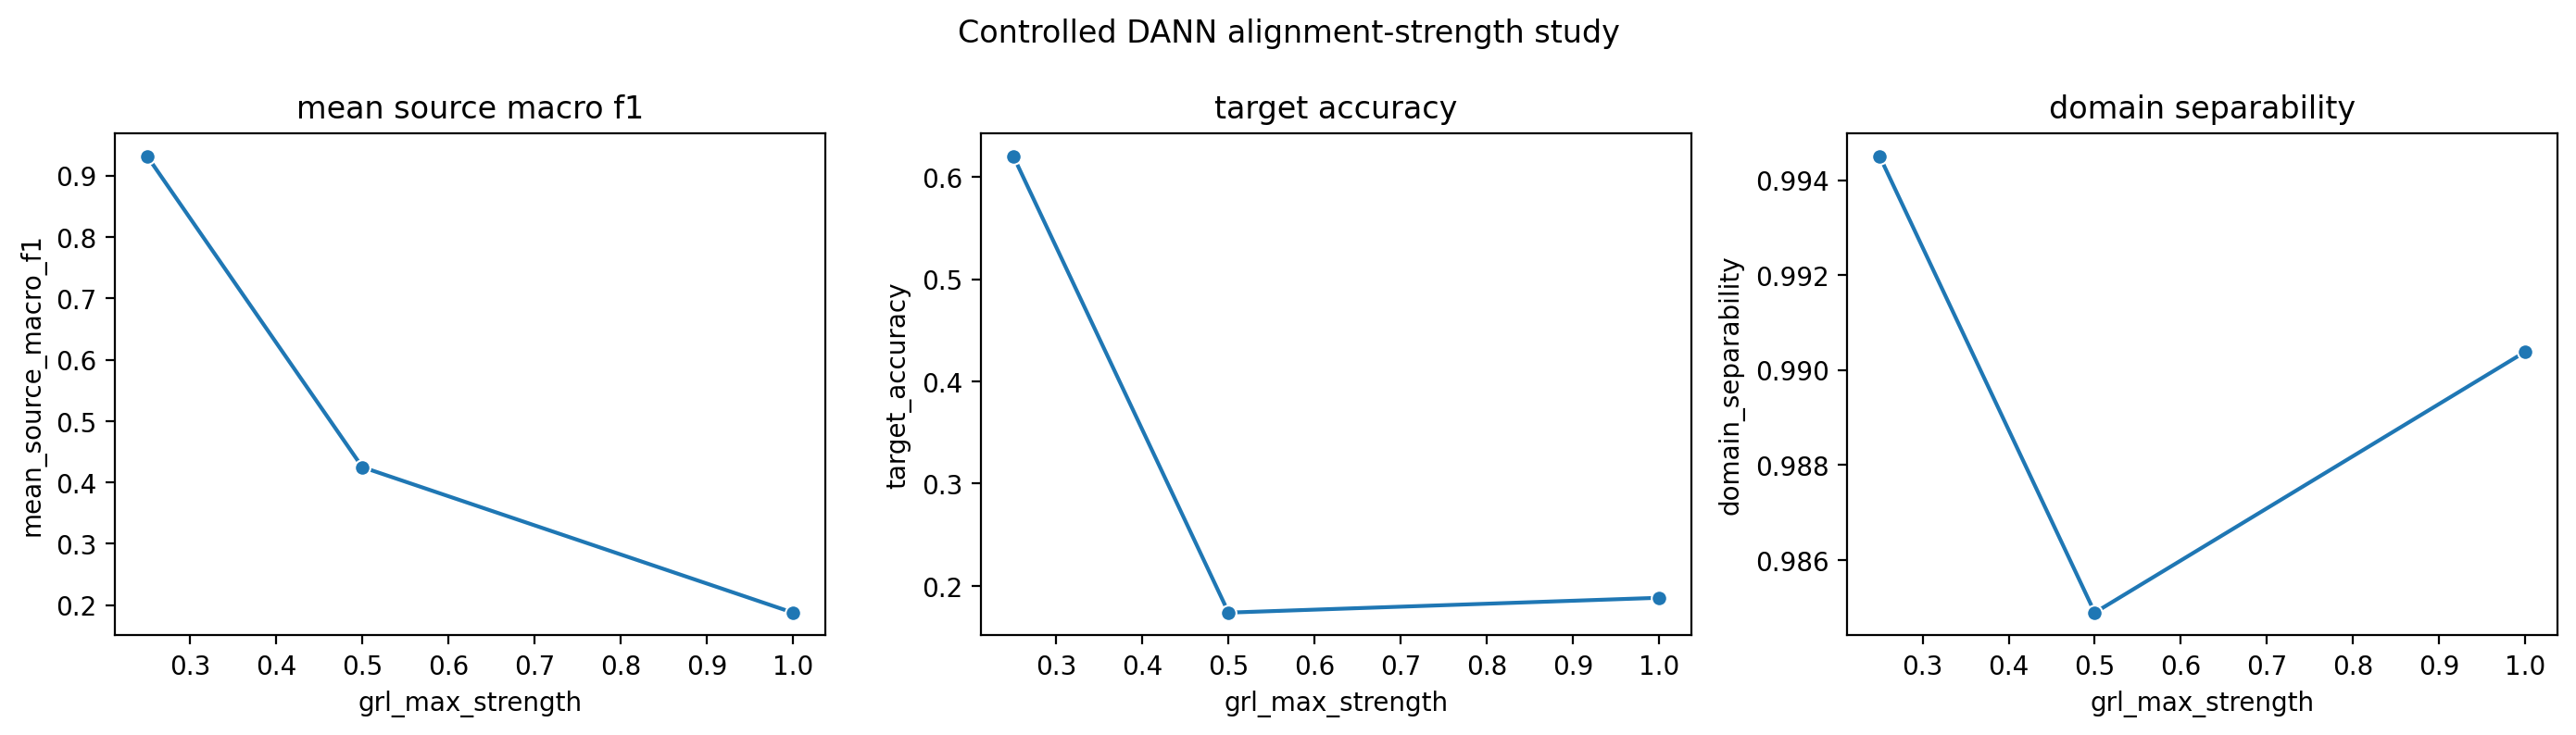

In [13]:
display(final["study"][["grl_max_strength", "mean_source_accuracy", "mean_source_macro_f1", "target_accuracy", "target_macro_f1", "domain_separability"]].round(4))
display(DisplayImage(filename=str(TASK_DIR / "results/dann_strength_study.png"), width=1000))

In [14]:
audit = pd.read_json(TASK_DIR / "results/completion_audit.json", typ="series")
display(audit.to_frame("value"))
print("Report-ready files:")
for path in sorted((TASK_DIR / "results").iterdir()):
    if path.is_file() and path.name != ".gitkeep": print(" -", path.name)

,value
required_outputs,"[source_split_summary.json, run_manifest.csv, ..."
main_methods,"[source_only, dan, dann, cdan]"
main_rows,4
per_class_rows,28
failure_case_comparison_method,cdan
target_labels_used_only_in_final_evaluation,True


Report-ready files:
 - class_transfer_extremes.csv
 - completion_audit.json
 - dann_strength_study.csv
 - dann_strength_study.png
 - dann_strength_training_curves.png
 - domain_separability.csv
 - domain_separability_vs_target_accuracy.png
 - final_comparison_all_runs.csv
 - main_method_comparison.csv
 - main_training_curves.png
 - run_manifest.csv
 - selected_target_failure_cases.csv
 - selected_target_failure_cases.png
 - source_split_summary.json
 - target_confusion_matrices.png
 - target_per_class_accuracy_changes.png
 - target_per_class_changes.csv
 - target_predictions.csv
 - training_history_all_runs.csv


In [15]:
import shutil
from IPython.display import FileLink, display
folder = "/kaggle/working/beyond-iid/domain-adaptation/results"
zip_path = shutil.make_archive(folder, "zip", root_dir=folder)
display(FileLink(zip_path))

/kaggle/working/beyond-iid/domain-adaptation/results.zip